In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Se importa el archivo como .CSV y se lo guarda en un set de datos.

In [101]:
df = pd.read_csv("Trabajo Integrador - Estadistica - Datos Brutos.csv", skiprows=2)
df = df.drop(columns=["Unnamed: 2"])
df.head()

,Horas de consumo de redes sociales por día,Rendimieno académico
0,5,7
1,1,8
2,3,8
3,3,8
4,6,7


# Se ajusta el nombre de las variables para hacerlas más accesibles

In [102]:
df = df.rename(columns={"Horas de  consumo de redes sociales por día": "x", "Rendimieno académico": "y"})
df.head()

,x,y
0,5,7
1,1,8
2,3,8
3,3,8
4,6,7


# Se guarda únicamente la variable xi (horas de consumo) y se calculan las frecuencias absolutas, frecuencias acumuladas, frecuencias relativas, frecuencias relativas acumuladas, y frecuencias porcentuales.

In [103]:
df_xi = df.copy()
df_xi = df_xi.drop(columns="y")
tabla_frecuencias = df_xi.groupby("x").size().reset_index(name="fi")
tabla_frecuencias = tabla_frecuencias.rename(columns={"x": "xi"})

n_datos = tabla_frecuencias["fi"].sum()

tabla_frecuencias["Fi"] = tabla_frecuencias["fi"].cumsum()
tabla_frecuencias["fri"] = tabla_frecuencias["fi"] / n_datos
tabla_frecuencias["Fri"] = tabla_frecuencias["fri"].cumsum()
tabla_frecuencias["pi%"] = tabla_frecuencias["fri"] * 100
tabla_frecuencias["Pi%"] = tabla_frecuencias["Fri"] * 100
tabla_frecuencias

,xi,fi,Fi,fri,Fri,pi%,Pi%
0,0,11,11,0.022449,0.022449,2.244898,2.244898
1,1,18,29,0.036735,0.059184,3.673469,5.918367
2,2,52,81,0.106122,0.165306,10.612245,16.530612
3,3,102,183,0.208163,0.373469,20.816327,37.346939
4,4,92,275,0.187755,0.561224,18.775510,56.122449
5,5,81,356,0.165306,0.726531,16.530612,72.653061
6,6,44,400,0.089796,0.816327,8.979592,81.632653
7,7,45,445,0.091837,0.908163,9.183673,90.816327
8,8,17,462,0.034694,0.942857,3.469388,94.285714
9,9,14,476,0.028571,0.971429,2.857143,97.142857


## a).
- Variable estadística: horas de consumo de redes sociales por día
- Tipo de variable: Cuantitativa continua
- Escala de medición: De Razón

## b). 
- Población: Grupo de Estudiantes
- Muestra: Los 490 estudiantes encuestados
- Unidad de observación: Cada estudiante encuestado

## d).
- f2: 18 estudiantes han pasado 1 hora por día en redes sociales.
- f5: 92 estudiantes han pasado 4 horas por día en redes sociales.
- f8: 45 estudiantes han pasado 7 horas por día en redes sociales.
- F4: 183 estudiantes han pasado hasta 3 horas por día en redes sociales.
- F7: 400 estudiantes han pasado hasta 6 horas por día en redes sociales.
- F10: 476 estudiantes han pasado hasta 9 horas por día en redes sociales.
- p3: Un 10,61% de los estudiantes han pasado 2 horas por día en redes sociales. 
- p6: Un 16,53% de los estudiantes han pasado 5 horas por día en redes sociales.
- p9: Un 3,46% de los estudiantes han pasado 8 horas por día en redes sociales.
- P8: Un 90,81% de los estudiantes han pasado hasta 7 horas por día en redes sociales.
- P12: Un 99,38% de los estudiantes han pasado hasta 11 horas por día en redes sociales.

## e).
- 382 estudiantes utilizan entre 3 y 8 horas diarias las redes sociales.
- Un 18,37% de estudiantes utilizan más de 6 horas diarias las redes sociales.
- 29 estudiantes utilizan menos de 2 horas diarias las redes sociales.
- Un 42,65% de los estudiantes utilizan entre 5 y 10 horas diarias las redes sociales.
- 28 estudiantes utilizan más de 8 horas diarias las redes sociales.
- Un 37,14% de los estudiantes utilizan menos de 4 horas diarias las redes sociales.
- 389 estudiantes utilizan entre 1 y 6 horas diarias las redes sociales.
- Un 2,86% de los estudiantes utilizan más de 9 horas diarias las redes sociales.

## f).

- Media aritmética = 4,47 horas: En promedio, los 490 estudiantes consumen casi 4 horas y media de redes sociales por día.

In [104]:
tabla_frecuencias["xi*fi"] = tabla_frecuencias["xi"] * tabla_frecuencias["fi"]
sum_xi_fi = tabla_frecuencias["xi*fi"].sum()
media_aritmetica = sum_xi_fi / n_datos
print("La media aritmética es:", f"{media_aritmetica:.2f}")

La media aritmética es: 4.47


- Moda = 3 horas: El valor que más se repite es 3 horas diarias, el cual es el consumo más frecuente entre los estudiantes.

In [105]:
# Se usa el dataframe que tiene los valores de x porque implica mayor facilidad para el cálculo de la moda.
moda = df_xi['x'].mode().tolist()
print("La moda es:",moda)

La moda es: [3]


- Mediana = 4 horas: La mitad de los estudiantes consume 4 horas o menos por día, y la otra mitad consume 4 horas o más.

In [106]:
# Se usa el dataframe que tiene los valores de x porque implica mayor facilidad para el cálculo de la mediana.
mediana = df_xi['x'].median()
print("La mediana es:",mediana)

La mediana es: 4.0


- Coeficiente de asimetría = 0, 66: Es positivo, lo que indica que la distribución es asimétrica hacia la derecha. Hay más estudiantes concentrados en consumos bajos y medios, pero algunos casos con consumos altos (10, 11, 12 horas) estiran la distribución hacia ese lado. La asimetría es moderada.

In [107]:
# Se usa el método de pandas skew() sobre el dataframe con los valores de x para calcular directamente el coeficiente de asimetría:
asimetria = df_xi['x'].skew()
print("El coeficiente de asimetría es:",f"{asimetria:.2f}")

El coeficiente de asimetría es: 0.66


- Curtosis = 0,53: Es positiva pero cercana a cero, resultando en una distribución levemente positiva. En la práctica, la distribución sería similar a una campana normal en cuanto a su forma.

In [108]:
# Se usa el método de pandas kurtosis() sobre el dataframe con los valores de x para calcular directamente la curtosis:
curtosis = df_xi['x'].kurtosis()
print("La curtosis es:", f"{curtosis:.2f}")

La curtosis es: 0.53


## g).

- Varianza = 5,04 horas²: Es la dispersión promedio al cuadrado. Por estar en unidades al cuadrado (horas²) no es tan intuitiva, pero sirve de base para la desviación estándar.

In [109]:
# Se usa el método de var() sobre el dataframe con los valores de x para calcular directamente la varianza:
varianza = df_xi["x"].var()
print("La varianza es:",f"{varianza:.2f}")

La varianza es: 5.04


- Desviación estándar = 2,24 horas: Los estudiantes se alejan en promedio 2,24 horas del consumo medio (4,47 hs). Es bastante común encontrar estudiantes entre 2 y 7 horas diarias.

In [110]:
# Se usa el método std() sobre el dataframe con los valores de x para calcular directamente la desviación estándar:
desviacion_estandar = df_xi["x"].std()
print("La desviación estándar es:",f"{desviacion_estandar:.2f}")

La desviación estándar es: 2.24


- Coeficiente de variación = 50.16%: Un CV del 50% indica que la dispersión es muy alta en relación a la media, los datos están muy esparcidos. Hay estudiantes con 0 horas y otros con 12, lo que genera mucha variación en la muestra.

In [111]:
# Cálculo de coeficiente de variación usando la desviación estándar y la media:
cv = (desviacion_estandar / df_xi['x'].mean()) * 100

print("El coeficiente de variación es:",f"{cv:.2f}%")

El coeficiente de variación es: 50.16%


## h).

- Q1 = 3 y Q3 = 6: El 25% de los estudiantes consume hasta 3 horas diarias, y el 75% consume hasta 6 horas.

In [112]:
# Cálculo de los cuartiles Q1 y Q3 usando el método quantile de pandas:
Q1 = df_xi["x"].quantile(0.25)
Q3 = df_xi["x"].quantile(0.75)
print("Q1:",Q1)
print("Q3",Q3)

Q1: 3.0
Q3 6.0


- D3 = 3, D4 = 4, D9 = 7: El 30% de los estudiantes consume hasta 3 horas, el 40% hasta 4 horas, y el 90% hasta 7 horas.

In [113]:
# Cálculo de los deciles D3, D4, D9:
D3 = df_xi["x"].quantile(0.30)
D4 = df_xi["x"].quantile(0.40)
D9 = df_xi["x"].quantile(0.90)
print("D3:",D3)
print("D4:",D4)
print("D9:",D9)

D3: 3.0
D4: 4.0
D9: 7.0


- P23 = 3, P75 = 6, P97 = 9: El 23% consume hasta 3 horas, el 75% hasta 6 horas, y el 97% hasta 9 horas.

In [114]:
# Cálculo de los percentiles P23, P75, P97:
P23 = df_xi["x"].quantile(0.23)
P75 = df_xi["x"].quantile(0.75)
P97 = df_xi["x"].quantile(0.97)
print("P23:",P23)
print("P75:",P75)
print("P97:",P97)

P23: 3.0
P75: 6.0
P97: 9.0


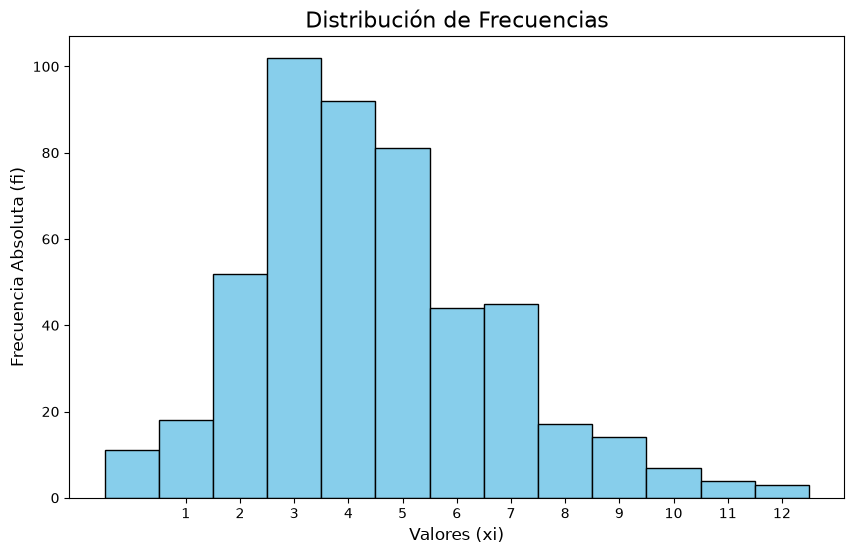

In [115]:
# 1. Configuración del tamaño del gráfico
plt.figure(figsize=(10, 6))

# 2. Se crea el gráfico de barras (actúa como histograma en este caso)
plt.bar(
    tabla_frecuencias['xi'],      # Eje X: Valores del 1 al 12
    tabla_frecuencias['fi'],      # Eje Y: Altura de las barras (frecuencia)
    color='skyblue',  # Color de relleno
    edgecolor='black',# Color del borde
    width=1.0         # Ancho de las barras (1.0 hace que se toquen, al estilo histograma)
)

# 3. Se agregan títulos y etiquetas
plt.title('Distribución de Frecuencias', fontsize=16)
plt.xlabel('Valores (xi)', fontsize=12)
plt.ylabel('Frecuencia Absoluta (fi)', fontsize=12)

# 4. Se muestran todos los números del 1 al 12 en el eje X
plt.xticks(range(1, 13))

# 5. Se muestra el gráfico
plt.show()

In [116]:
n_datos

np.int64(490)

In [117]:
print("Variable X: Horas de consumo de redes sociales por día")
print("Variable Y: Rendimiento académico")

Variable X: Horas de consumo de redes sociales por día
Variable Y: Rendimiento académico


# Se crean columnas para guardar los datos necesarios para aplicar la Regresión Lineal

In [118]:
df["x*y"] = df["x"]*df["y"]
df["x^2"] = df["x"] ** 2
df["y^2"] = df["y"] ** 2
df.head()

,x,y,x*y,x^2,y^2
0,5,7,35,25,49
1,1,8,8,1,64
2,3,8,24,9,64
3,3,8,24,9,64
4,6,7,42,36,49


In [119]:
n = 489
sum_x = df["x"].sum()
sum_y = df["y"].sum()
sum_xy = df["x*y"].sum()
sum_x2 = df["x^2"].sum()
sum_y2 = df["y^2"].sum()
print("Sumatoria de X:",sum_x)
print("Sumatoria de Y:",sum_y)
print("Sumatoria de X*Y:",sum_xy)
print("Sumatoria de X^2:",sum_x2)
print("Sumatoria de Y^2:",sum_y2)

Sumatoria de X: 2192
Sumatoria de Y: 3468
Sumatoria de X*Y: 14975
Sumatoria de X^2: 12268
Sumatoria de Y^2: 24892


In [120]:
b = ((n * sum_xy) - (sum_x * sum_y)) / ((n * sum_x2) - (sum_x ** 2))
a = ((sum_y * sum_x2) - (sum_xy * sum_x)) / ((n * sum_x2) - (sum_x ** 2))
print("Pendiente b:",f"{b:.2f}")
print("Ordenada al origen a:",f"{a:.2f}")
print("Ecuación de recta de regresión y = -0.23x + 8.14")

Pendiente b: -0.23
Ordenada al origen a: 8.14
Ecuación de recta de regresión y = -0.23x + 8.14


## Ecuación de regresión: y = -0.23x + 8.14
- Ordenada al origen (a = 8.14): Un estudiante que no consume redes sociales en absoluto tendría un rendimiento académico estimado de 8.14 puntos.
- Pendiente (b = -0.23): Por cada hora adicional de redes sociales por día, el rendimiento académico cae en promedio 0.23 puntos. Un estudiante que pasa 5 horas diarias en redes tendría un rendimiento esperado de unos 6.99 puntos, contra los 8.13 de alguien que no las usa, una diferencia de más de un punto.

In [121]:
r = ((n * sum_xy) - (sum_x * sum_y)) / np.sqrt(((n * sum_x2) - (sum_x ** 2)) * ((n * sum_y2) - (sum_y ** 2)))
r2 = r**2
print("Coeficiente de correlación r:",f"{r:.2f}")
print("R^2:",f"{r2:.2f}")

Coeficiente de correlación r: -0.67
R^2: 0.45


## Coeficiente de correlación: r = -0.67
- El signo negativo confirma que la relación es inversa: más redes, menos rendimiento. La magnitud (-0.67) indica una correlación moderada. No es débil ni fuerte: existe una tendencia clara, pero hay mucha variabilidad individual, hay estudiantes que usan muchas horas de redes y tienen un buen rendimiento, y viceversa.

## Coeficiente de determinación: R² = 0.45
- El consumo de redes sociales explica el 45% de la variación en el rendimiento académico.

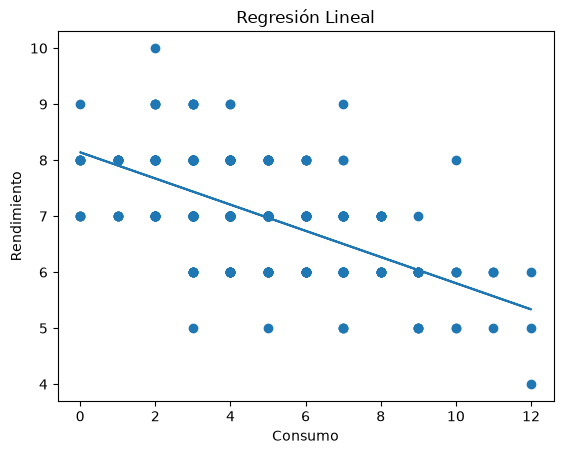

In [122]:
x = np.array(df["x"])
y = a + b*x

plt.scatter(df["x"], df["y"])
plt.plot(x, y)

plt.title("Regresión Lineal")
plt.xlabel("Consumo")
plt.ylabel("Rendimiento")

plt.show()


# El gráfico muestra una tendencia descendente real pero con una notoria variabilidad individual. La recta captura la tendencia general, pero predecir el rendimiento de un estudiante puntual a partir de su consumo de redes sería impreciso.